In [1]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
data = pd.read_csv ("Labeling.csv")

In [3]:
df = data 

In [4]:
df.head(10)

,text,text_clean,token,stop,stemmed,sentiment
0,Calon Presiden Indonesia Ganjar Pranowo bersil...,calon presiden indonesia ganjar pranowo bersil...,"['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...","['calon', 'presiden', 'indonesia', 'ganjar', '...",netral
1,*KODE ALAM DAN TANDA ZAMAN SIAPA PRESIDEN RI K...,kode alam dan tanda zaman siapa presiden ri ke...,"['kode', 'alam', 'dan', 'tanda', 'zaman', 'sia...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...","['kode', 'alam', 'tanda', 'zaman', 'siapa', 'p...",netral
2,@ch_chotimah2 Dulu waktu AHY calon gubernur di...,chchotimah dulu waktu ahy calon gubernur di dk...,"['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...","['chchotimah', 'dulu', 'waktu', 'ahy', 'calon'...",netral
3,"Sang calon presiden Indonesia, Ganjar Pranowo ...",sang calon presiden indonesia ganjar pranowo t...,"['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...","['sang', 'calon', 'presiden', 'indonesia', 'ga...",netral
4,Banyak tokoh yang digadang-gadang jadi calon w...,banyak tokoh yang digadanggadang jadi calon wa...,"['banyak', 'tokoh', 'yang', 'digadanggadang', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...","['banyak', 'tokoh', 'digadanggadang', 'jadi', ...",netral
5,Ganjar Pranowo mengajak partai politik penduku...,ganjar pranowo mengajak partai politik penduku...,"['ganjar', 'pranowo', 'mengajak', 'partai', 'p...","['ganjar', 'pranowo', 'mengajak', 'partai', 'p...","['ganjar', 'pranowo', 'mengajak', 'partai', 'p...",netral
6,Bakal calon presiden (bacapres) dari Partai Ge...,bakal calon presiden bacapres dari partai geri...,"['bakal', 'calon', 'presiden', 'bacapres', 'da...","['bakal', 'calon', 'presiden', 'bacapres', 'pa...","['bakal', 'calon', 'presiden', 'bacapres', 'pa...",netral
7,@yodisss Seneng bgt nih pasti masyarakat Lombo...,yodisss seneng bgt nih pasti masyarakat lombok...,"['yodisss', 'seneng', 'bgt', 'nih', 'pasti', '...","['yodisss', 'seneng', 'bgt', 'nih', 'masyaraka...","['yodisss', 'seneng', 'bgt', 'nih', 'masyaraka...",netral
8,Bakal calon presiden yang juga Menteri Pertaha...,bakal calon presiden yang juga menteri pertaha...,"['bakal', 'calon', 'presiden', 'yang', 'juga',...","['bakal', 'calon', 'presiden', 'menteri', 'per...","['bakal', 'calon', 'presiden', 'menteri', 'per...",netral
9,Mereka yg masih mempersoalkan seorang presiden...,mereka yg masih mempersoalkan seorang presiden...,"['mereka', 'yg', 'masih', 'mempersoalkan', 'se...","['yg', 'mempersoalkan', 'seorang', 'presidenca...","['yg', 'mempersoalkan', 'seorang', 'presidenca...",netral


In [5]:
df.tail()

,text,text_clean,token,stop,stemmed,sentiment
3137,Ganjar Capres 2024 pilihan rakyat Indonesia\n#...,ganjar capres pilihan rakyat indonesia\nganja...,"['ganjar', 'capres', 'pilihan', 'rakyat', 'ind...","['ganjar', 'capres', 'pilihan', 'rakyat', 'ind...","['ganjar', 'capres', 'pilihan', 'rakyat', 'ind...",netral
3138,"Dua hal yang bisa menjegal si ""pembual"" Anies ...",dua hal yang bisa menjegal si pembual anies ma...,"['dua', 'hal', 'yang', 'bisa', 'menjegal', 'si...","['menjegal', 'si', 'pembual', 'anies', 'maju',...","['menjegal', 'si', 'pembual', 'anies', 'maju',...",netral
3139,Video: Naik Turun Elektabilitas Capres 2024 ht...,video naik turun elektabilitas capres httpstc...,"['video', 'naik', 'turun', 'elektabilitas', 'c...","['video', 'naik', 'turun', 'elektabilitas', 'c...","['video', 'naik', 'turun', 'elektabilitas', 'c...",netral
3140,capres 2024 https://t.co/0uFSg1xtAQ,capres httpstcoufsgxtaq,"['capres', 'httpstcoufsgxtaq']","['capres', 'httpstcoufsgxtaq']","['capres', 'httpstcoufsgxtaq']",netral
3141,@likechizu KIM NAMJOON CAPRES 2024!!!,likechizu kim namjoon capres,"['likechizu', 'kim', 'namjoon', 'capres']","['likechizu', 'kim', 'namjoon', 'capres']","['likechizu', 'kim', 'namjoon', 'capres']",netral


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        3142 non-null   object
 1   text_clean  3142 non-null   object
 2   token       3142 non-null   object
 3   stop        3142 non-null   object
 4   stemmed     3142 non-null   object
 5   sentiment   3142 non-null   object
dtypes: object(6)
memory usage: 147.4+ KB


In [7]:
df ['text'] = df['text'].astype('str')
df ['sentiment'] = df['sentiment'].astype('str')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        3142 non-null   object
 1   text_clean  3142 non-null   object
 2   token       3142 non-null   object
 3   stop        3142 non-null   object
 4   stemmed     3142 non-null   object
 5   sentiment   3142 non-null   object
dtypes: object(6)
memory usage: 147.4+ KB


In [8]:
X_train, X_test, y_train, y_test = train_test_split(df['text'].values, df['sentiment'].values, 
                                                    test_size = 0.20, 
                                                    random_state = 0)

In [9]:
print (X_train.shape)
print (y_train.shape)
print (X_test.shape)
print (y_test.shape)

(2513,)
(2513,)
(629,)
(629,)


In [10]:
vectorizer = CountVectorizer()
vectorizer.fit(X_train)

CountVectorizer()

In [11]:
data_train = vectorizer.transform(X_train)
data_test = vectorizer.transform(X_test)

In [12]:
print(data_train)

  (0, 8)	1
  (0, 91)	1
  (0, 393)	1
  (0, 870)	1
  (0, 936)	1
  (0, 1413)	1
  (0, 1538)	1
  (0, 1686)	1
  (0, 2125)	1
  (0, 2895)	1
  (0, 4200)	1
  (0, 5065)	1
  (0, 5387)	1
  (0, 5912)	2
  (0, 6456)	1
  (0, 6903)	1
  (1, 89)	1
  (1, 108)	1
  (1, 1139)	1
  (1, 1352)	1
  (1, 1397)	1
  (1, 1538)	1
  (1, 1641)	1
  (1, 1752)	2
  (1, 2371)	1
  :	:
  (2511, 391)	1
  (2511, 1413)	1
  (2511, 3164)	1
  (2511, 4328)	1
  (2511, 6615)	1
  (2511, 7965)	1
  (2512, 91)	1
  (2512, 839)	1
  (2512, 1214)	1
  (2512, 1293)	1
  (2512, 1315)	1
  (2512, 1413)	1
  (2512, 1641)	1
  (2512, 3009)	1
  (2512, 3446)	1
  (2512, 4512)	1
  (2512, 5100)	1
  (2512, 5309)	1
  (2512, 5325)	1
  (2512, 5460)	1
  (2512, 5799)	1
  (2512, 5965)	1
  (2512, 6463)	1
  (2512, 6863)	1
  (2512, 7524)	1


In [13]:
print(data_test)

  (0, 91)	1
  (0, 478)	1
  (0, 489)	1
  (0, 1184)	1
  (0, 1212)	1
  (0, 1413)	1
  (0, 1419)	1
  (0, 1753)	1
  (0, 2428)	1
  (0, 2565)	1
  (0, 3164)	1
  (0, 3236)	1
  (0, 4029)	1
  (0, 4219)	1
  (0, 5317)	1
  (0, 5372)	1
  (0, 5799)	1
  (0, 5912)	1
  (0, 6406)	1
  (0, 6579)	1
  (0, 6982)	1
  (0, 7981)	1
  (1, 91)	1
  (1, 1413)	1
  (1, 1538)	1
  :	:
  (627, 545)	1
  (627, 839)	1
  (627, 1154)	1
  (627, 1210)	1
  (627, 1397)	1
  (627, 1538)	1
  (627, 1683)	1
  (627, 1757)	1
  (627, 2895)	1
  (627, 4514)	1
  (627, 5573)	1
  (627, 5912)	1
  (627, 5933)	1
  (627, 6712)	1
  (627, 7256)	1
  (627, 7748)	1
  (627, 7949)	1
  (627, 7965)	1
  (628, 91)	1
  (628, 1413)	1
  (628, 1538)	1
  (628, 2125)	1
  (628, 2459)	1
  (628, 2895)	1
  (628, 5927)	1


In [14]:
model = SVC(kernel = 'linear', random_state = 10)
model.fit(data_train, y_train)

SVC(kernel='linear', random_state=10)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3142 entries, 0 to 3141
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        3142 non-null   object
 1   text_clean  3142 non-null   object
 2   token       3142 non-null   object
 3   stop        3142 non-null   object
 4   stemmed     3142 non-null   object
 5   sentiment   3142 non-null   object
dtypes: object(6)
memory usage: 147.4+ KB


In [15]:
prediction = model.predict(data_test)
prediction

array(['netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'negatif', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'netral',
       'netral', 'positif', 'netral', 'netral', 'netral', 'netral',
       'netral', 'netral', 'netral', 'netral', 'netral', 'ne

In [16]:
score = accuracy_score(y_test, prediction)

In [17]:
print ( "accuracy_score:" , score*100, '%')
print ('====================================================\n')
print(f'confusion_matrix:\n {confusion_matrix(y_test, prediction)}')
print('====================================================\n')
print(classification_report(y_test, prediction))

accuracy_score: 97.2972972972973 %

confusion_matrix:
 [[  3   5   0]
 [  0 598   0]
 [  0  12  11]]

              precision    recall  f1-score   support

     negatif       1.00      0.38      0.55         8
      netral       0.97      1.00      0.99       598
     positif       1.00      0.48      0.65        23

    accuracy                           0.97       629
   macro avg       0.99      0.62      0.73       629
weighted avg       0.97      0.97      0.97       629



In [17]:
conf_matrix = confusion_matrix (y_test, prediction)

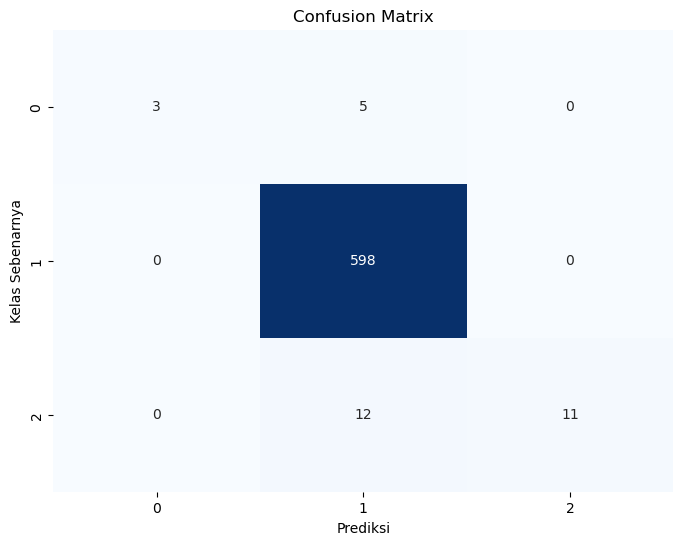

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.xlabel('Prediksi')
plt.ylabel('Kelas Sebenarnya')
plt.title('Confusion Matrix')
plt.show()

In [19]:
jumlah_positif = 8
jumlah_netral = 598
jumlah_negatif = 23

In [20]:
sentiments = ['Positif','netral', 'Negatif']
counts = [jumlah_positif, jumlah_netral, jumlah_negatif]

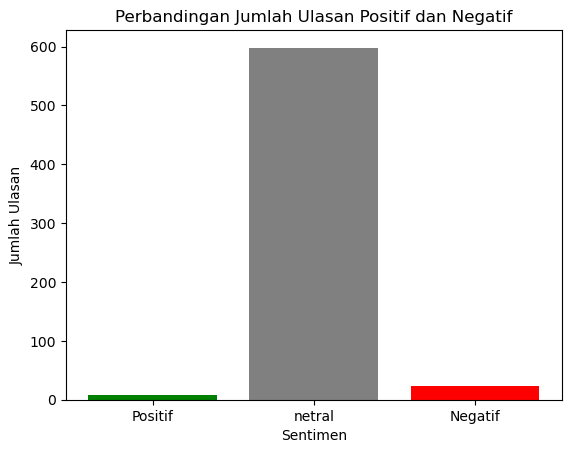

In [21]:
plt.bar(sentiments, counts, color=['green', 'gray', 'red'])
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.title('Perbandingan Jumlah Ulasan Positif dan Negatif')
plt.show()